Raw/original data preview:
                               skill  \
0          Data modelling and design   
1       Data and database management   
2  Data and database query languages   
3                   Data acquisition   
4                      Data cleaning   
5                     Data wrangling   
6                      Data curation   
7                 Metadata standards   
8         Data protection and ethics   
9          Data lifecycle management   

                                         description  Data steward  \
0  Ability to plan, architect and implement data ...           3.0   
1  Ability to effectively select a data storage s...           NaN   
2  Proficiency in data or database query language...           NaN   
3  Ability to identify, collect and process data ...           1.0   
4  Ability to identify, correct and remove errors...           1.0   
5  Ability to transform raw, messy data into clea...           NaN   
6  Ability to steward and enrich data to e

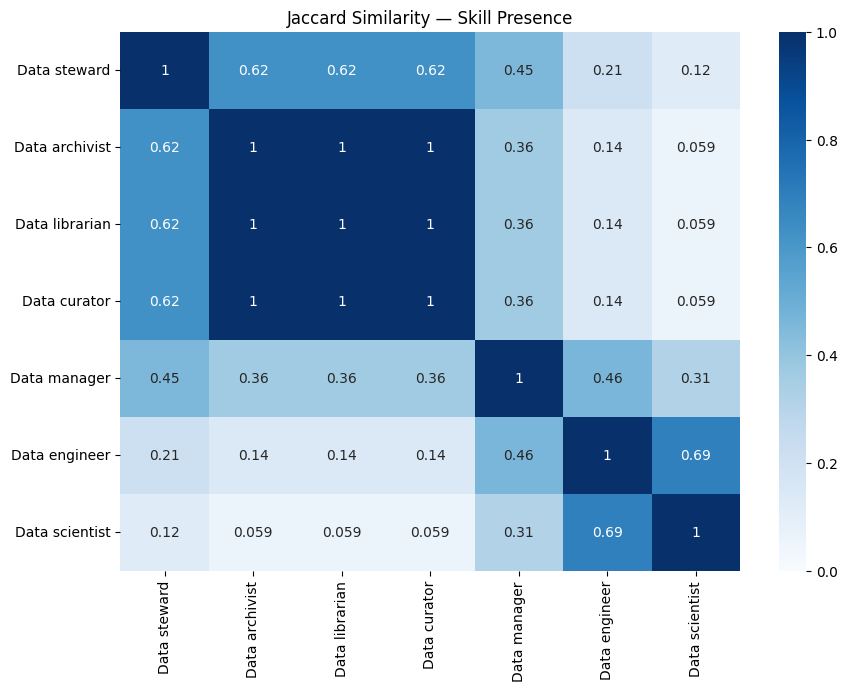

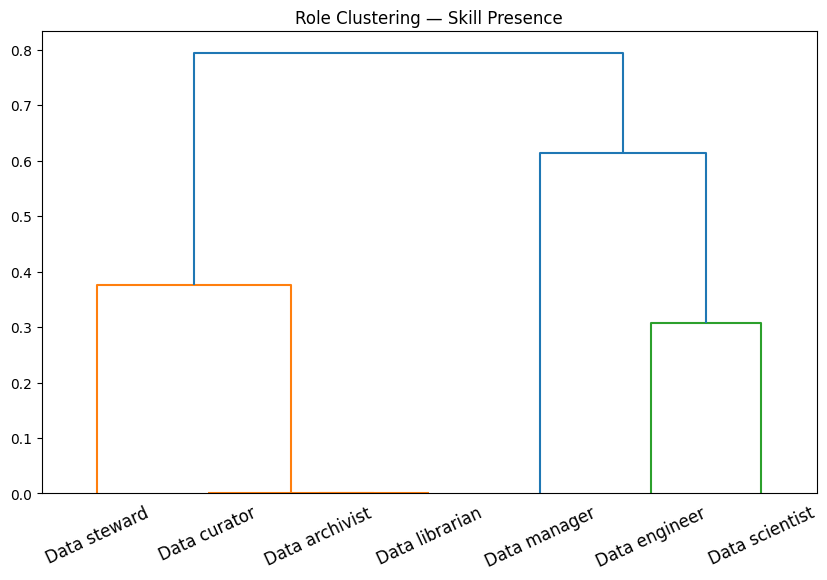

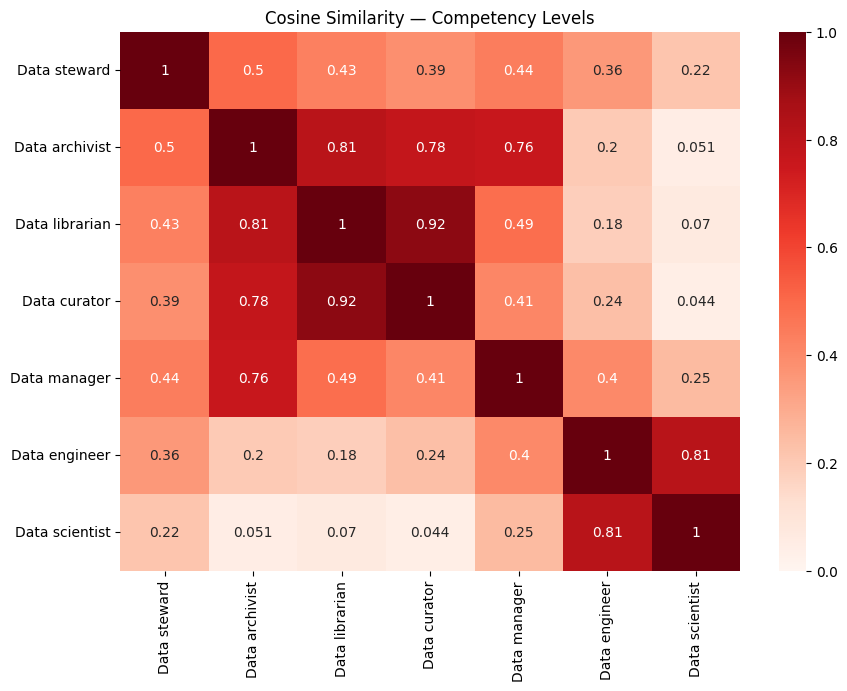

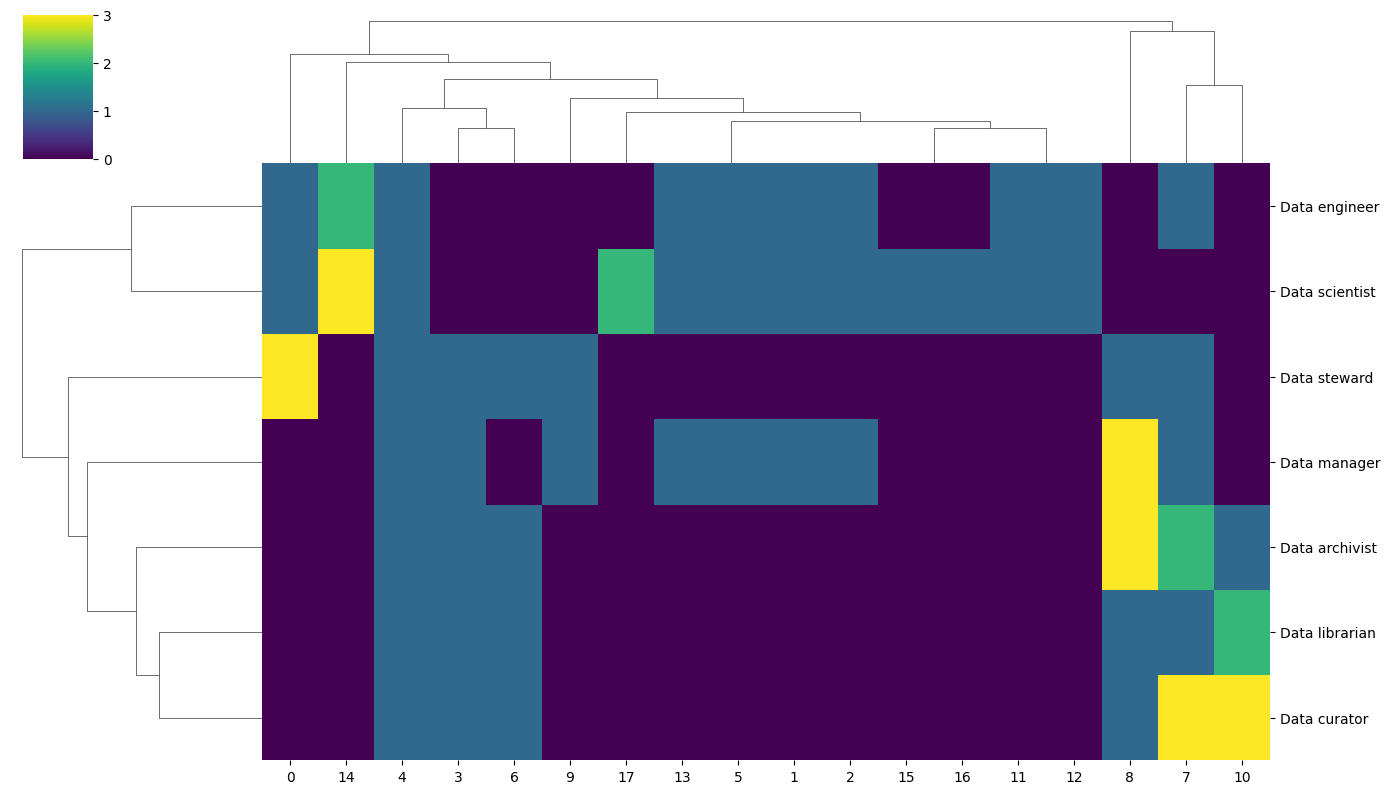

In [5]:
%matplotlib inline

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import jaccard_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# -----------------------------
# CONFIGURATION
# -----------------------------

# Google Sheet ID
# Replace with your own sheet ID
google_sheet_id = "13mr_ZsaJKf0sG7Qk7qIl6ArohvDde_44FTxiAcgaBbk"

# Optional: worksheet/tab name
sheet_name = "Sheet1"

role_columns = [
    "Data steward",
    "Data archivist",
    "Data librarian",
    "Data curator",
    "Data manager",
    "Data engineer",
    "Data scientist"
]

skill_column = "skill"

# -----------------------------
# LOAD + CLEAN DATA
# -----------------------------

# OLD LOCAL CSV VERSION
# csv_file = "skills-roles.csv"
# df = pd.read_csv(csv_file)

# NEW GOOGLE SHEETS VERSION
google_sheet_url = (
    f"https://docs.google.com/spreadsheets/d/"
    f"{google_sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
)

df = pd.read_csv(google_sheet_url)

# Clean column names
df.columns = df.columns.str.strip()

print("Raw/original data preview:")
print(df.head(10))

# -----------------------------
# SELECT DATA
# -----------------------------

skills = df[skill_column]

roles_df = df[role_columns]

# Convert to numeric
roles_df = roles_df.fillna(0)
roles_df = roles_df.apply(pd.to_numeric, errors='coerce')
roles_df = roles_df.astype(int)

print("\nRole data preview:")
print(roles_df.head(10))

# =========================================================
# PART 1 — SKILL PRESENCE (BINARY ANALYSIS)
# =========================================================

# Create binary dataframe
binary_df = (roles_df > 0).astype(int)

roles = binary_df.columns

# Jaccard similarity matrix
jaccard_matrix = pd.DataFrame(
    index=roles,
    columns=roles
)

for r1 in roles:
    for r2 in roles:
        jaccard_matrix.loc[r1, r2] = jaccard_score(
            binary_df[r1],
            binary_df[r2]
        )

jaccard_matrix = jaccard_matrix.astype(float)

# -----------------------------
# VISUALISATION 1
# JACCARD HEATMAP
# -----------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    jaccard_matrix,
    annot=True,
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title("Jaccard Similarity — Skill Presence")

plt.show()

# -----------------------------
# VISUALISATION 2
# DENDROGRAM
# -----------------------------

distance_matrix = pdist(
    binary_df.T,
    metric='jaccard'
)

linkage_matrix = linkage(
    distance_matrix,
    method='average'
)

plt.figure(figsize=(10, 6))

dendrogram(
    linkage_matrix,
    labels=roles,
    leaf_rotation=25
)

plt.title("Role Clustering — Skill Presence")

plt.show()

# =========================================================
# PART 2 — COMPETENCY LEVEL ANALYSIS
# =========================================================

numeric_df = roles_df.copy()

# Cosine similarity
cosine_matrix = cosine_similarity(
    numeric_df.T
)

cosine_df = pd.DataFrame(
    cosine_matrix,
    index=roles,
    columns=roles
)

# -----------------------------
# VISUALISATION 3
# COSINE HEATMAP
# -----------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    cosine_df,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=1
)

plt.title("Cosine Similarity — Competency Levels")

plt.show()

# -----------------------------
# VISUALISATION 4
# CLUSTERED HEATMAP
# -----------------------------

# Remove constant columns for stability
cluster_df = numeric_df.loc[
    :,
    numeric_df.nunique() > 1
]

sns.clustermap(
    cluster_df.T,
    cmap="viridis",
    figsize=(14, 8)
)

plt.show()